In [1]:
try:
    import pandas as pd
    import json
    import statsmodels.api as sm
    from statsmodels.regression.linear_model import OLS
    import matplotlib.pyplot as plt
    import numpy as np
except ImportError:
    !pip install pandas
    !pip install statsmodels
    !pip install matplotlib.pyplot
    !pip install numpy
    import numpy as np
    import matplotlib as plt
    import pandas as pd
    import statsmodels.api as sm
    from statsmodels.regression.linear_model import OLS

In [2]:
# Убрать ограничение на количество отображаемых строк
pd.set_option('display.max_rows', 200)  # None означает "без ограничений"
pd.set_option('display.max_columns', 200)  # для столбцов

# Если нужно вернуть настройки по умолчанию:
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')



***Модуль подготовки исторических данных***

In [3]:
LOAD_TABLE_PATH = 'C:\\Users\\PATH'
AHT_TABLE_PATH = 'C:\\Users\\PATH'

class DataLoader:
    def __init__(self, load_path, aht_path):
        self.load_path = load_path
        self.aht_path = aht_path
        self.load_table = None
        self.aht_table = None
        self.load_data()
        self.preprocess_data()
        self.get_aht()

    def load_data(self):
        self.load_table = pd.read_excel(self.load_path)
        self.aht_table = pd.read_excel(self.aht_path)
        return self.load_table, self.aht_table

    def preprocess_data(self):
        # Предварительная обработка данных
        self.load_table['last_date'], self.load_table['first_date'] = (
            self.load_table.groupby('queueId')['dateTime_scaled'].transform('max'),
            self.load_table.groupby('queueId')['dateTime_scaled'].transform('min')
        )
        
        self.load_table['prev_month_date'] = self.load_table['last_date'] - pd.DateOffset(months=1)
        self.load_table['date'] = pd.to_datetime(self.load_table['dateTime_scaled'].dt.date)
        self.load_table['day'] = self.load_table['date'].dt.dayofweek
        self.load_table['hour'] = self.load_table['dateTime_scaled'].dt.hour
        self.load_table['interval'] = (self.load_table['dateTime_scaled'].dt.minute) // 15 + 1
        return self.load_table
    
    # Интересная альтернатива merge
    def get_aht(self):
        self.load_table['aht'] = self.load_table.apply(
            lambda row:
                self.aht_table.loc[
                    (self.aht_table['dateTime_scaled'].dt.day == row['dateTime_scaled'].day) &
                    (self.aht_table['queueId'] == row['queueId']),
                    'aht'
                ].values[0] 
                if not self.aht_table[
                    (self.aht_table['dateTime_scaled'].dt.day == row['dateTime_scaled'].day) &
                    (self.aht_table['queueId'] == row['queueId'])
                ].empty 
                else None,
            axis=1
        ) 
        return self.load_table
    
data_loader = DataLoader(LOAD_TABLE_PATH, AHT_TABLE_PATH)

In [4]:
# Делаем "панель управления", по которой можно будет в дальнейшем добавлять очереди, группировать по нужным командам и тд.
data = {
    "queues": [
        {
            "queue_id": 999,
            "team": "Support Team A",
            "metrics": [{
                "aht": 300,
                "count": 150,
                "bottom": 0.25,
                "ceiling": 0.75,
                "automatization_rate": 0.6,
                "aggregation": "1",
                "first_date": "2025-06-01",
                "last_date": "2025-06-30"
            }]
        },
        {
            "queue_id": 106797,
            "team": "Support Team B",
            "metrics": [{
                "aht": 350,
                "count": 120,
                "bottom": 0.25,
                "ceiling": 0.75,
                "automatization_rate": 0.5,
                "aggregation": "2",
                "first_date": "2025-06-01",
                "last_date": "2025-06-30"
            }]
        }
    ]
}

# Делаем список с праздниками или особыми днями, для которых нужен отдельный расчет сезонности
event_dates = ['2025-06-30', '2025-06-29']

class ControlTable(DataLoader):
    def __init__(self, event_dates, data, load_table):
        self.event_dates = event_dates
        self.data = data
        self.load_table = load_table
        self.control_table = self.normalize_json()
        self.central_table = self.create_central_table()
        self.update_load_table()
        
    def normalize_json(self):
        self.control_table = pd.json_normalize(self.data['queues'], 
                   record_path=['metrics'], 
                   meta=['queue_id', 'team'])
        return self.control_table
    
    #Подготавлияваем данные, делаем центральную таблицу, из которой будем тянуть данные, считать общие параметры на группы
    def create_central_table(self):
        self.central_table = self.load_table[(self.load_table['dateTime_scaled'] > self.load_table['prev_month_date'])
                          ].groupby('queueId').agg(month_id_count=('globalId', 'sum'),
                        month_aht_avg=('aht', 'mean'),  
                         month_automatization_count=('is_automatization', 'sum'),
                         last_date=('last_date', 'max'),
                         first_date=('first_date', 'min')
                        )
        self.central_table = self.central_table.merge(self.control_table[['ceiling', 'bottom', 'automatization_rate', 'queue_id', 'team']],
                                                 left_on='queueId', right_on='queue_id', how='right')
        return self.central_table
    #Возвращаем load_table с обновлением из central
    def update_load_table(self):
        self.load_table = self.load_table.merge(self.central_table[['queue_id', 'team']],
                                      left_on='queueId', right_on='queue_id', how='left').drop('queue_id', axis=1)
        return self.load_table
      
control_table =  ControlTable(event_dates, data, data_loader.load_table)  
display(control_table.control_table, control_table.central_table, control_table.load_table)

,aht,count,bottom,ceiling,automatization_rate,aggregation,first_date,last_date,queue_id,team
0,300,150,0.25,0.75,0.6,1,2025-06-01,2025-06-30,999,Support Team A
1,350,120,0.25,0.75,0.5,2,2025-06-01,2025-06-30,106797,Support Team B


,month_id_count,month_aht_avg,month_automatization_count,last_date,first_date,ceiling,bottom,automatization_rate,queue_id,team
0,56141.0,757.879476,0.0,2025-07-23 23:45:00,2025-06-17,0.75,0.25,0.6,999,Support Team A
1,NaN,NaN,NaN,NaT,NaT,0.75,0.25,0.5,106797,Support Team B


,dateTime_scaled,queueId,globalId,is_automatization,last_date,first_date,prev_month_date,date,day,hour,interval,aht,team
0,2025-07-23 23:45:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
1,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
2,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
3,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
4,2025-07-23 23:45:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20419,2025-06-17 00:00:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A
20420,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A
20421,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A
20422,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A


In [5]:
team_a = 'Support Team A'

# Подготавливаем базу для прогноза
class DataPreparation:
    def __init__(self, load_table, team):
        self.team = team
        self.load_table = load_table
        self.historical_sample = self.prepare_historical_sample()
        self.model = self.create_reg_params()
        
    # Суммируем количество нагрузки по дням, создаем независимую переменную number    
    def prepare_historical_sample(self):
        self.historical_sample = pd.DataFrame(self.load_table[self.load_table['team'] == self.team].
                                              groupby('date')['globalId'].sum()).sort_values(by='date', ascending=True)
        self.historical_sample.reset_index(drop=False, inplace=True)
        self.historical_sample['number'] = [x+1 for x in range(len(self.historical_sample.index))]
        self.historical_sample['day'] = self.historical_sample['date'].dt.dayofweek
        return self.historical_sample
    
    # Рассчитываем коэффициенты a и b для регрессии
    def create_reg_params(self):
        X = self.historical_sample['number']
        Y = self.historical_sample['globalId']
        X = sm.add_constant(X, prepend=False)
        self.model = OLS(Y, X)  
        return self.model  
        
prognosis_set_a = DataPreparation(control_table.load_table, team_a)
historical_sample_a = prognosis_set_a.historical_sample
model_a = prognosis_set_a.model

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


***Модуль прогнозирования по дням линейной регрессией***

In [6]:
class PrognosisSample:
    def __init__(self, historical_sample, model):
        self.historical_sample = historical_sample
        self.model = model
        self.prediction_sample = self.create_prediction_sample()
    
    def create_prediction_sample(self):
        # Расширяем список на нужный нам размер, здесь 1000, и нумеруем (number)
        self.prediction_sample = self.historical_sample.reindex(range(1000))
        self.prediction_sample['number'] = [x+1 for x in range(len(self.prediction_sample.index))]

        # Определяем начало и конец
        start_date = max(self.prediction_sample['date']) + pd.Timedelta(days=1)
        start_index = self.prediction_sample[self.prediction_sample['date']==max(self.prediction_sample['date'])].index[0]+1
        end_date = '2026-01-01'
        end_index = max(self.prediction_sample.index)

        # Создаем диапазон дат
        date_range = pd.DataFrame(pd.date_range(start=start_date, end=end_date))
        date_range.index = range(start_index, len(date_range)+start_index)

        # Объединяем фреймы
        self.prediction_sample = self.prediction_sample.merge(date_range, left_index=True, right_index=True, how='outer')
        self.prediction_sample['date'] = self.prediction_sample.apply(lambda x: x[0] if pd.isna(x['date']) else x['date'], axis=1)
        self.prediction_sample = self.prediction_sample.drop(columns=[0])

        # Добавляем день недели
        self.prediction_sample['day'] = self.prediction_sample['date'].dt.dayofweek

        # Рассчитываем коэффициенты
        res = self.model.fit()
        a_coef = res.params[0]
        b_coef = res.params[1]  

        # Строим линию тренда
        self.prediction_sample['trend'] = b_coef + (0 * self.prediction_sample['number'])
        return self.prediction_sample 

class Medians:
    def __init__(self, prediction_sample, max_date_historical, event_dates):
        self.prediction_sample = prediction_sample
        self.max_date_historical = max_date_historical
        self.event_dates = event_dates
        self.days_median_difference, self.median_threshold = self.find_day_median_difference()
        self.events_median_difference = self.find_event_median_difference()
    
    def find_day_median_difference(self):
        self.prediction_sample = self.prediction_sample.copy()
        self.median_threshold = self.max_date_historical - pd.Timedelta(days=96)
        self.prediction_sample['day_difference'] = self.prediction_sample['globalId'] - self.prediction_sample['trend']
        
        days_median_difference = self.prediction_sample[
            (self.prediction_sample['date'] >= self.median_threshold) &
            (~self.prediction_sample['date'].isin(self.event_dates))
        ].groupby('day')['day_difference'].median()
        return days_median_difference, self.median_threshold
    
    def find_event_median_difference(self):
        self.prediction_sample = self.prediction_sample.copy()
        self.prediction_sample['event_difference'] = self.prediction_sample[self.prediction_sample['date'].
                                                                            isin(self.event_dates)]['globalId'] - self.prediction_sample['trend']
        
        events_median_difference = self.prediction_sample[
            (self.prediction_sample['date'] >= self.median_threshold) &
            (self.prediction_sample['date'].isin(self.event_dates))
        ].groupby('date')['event_difference'].median()
        
        return events_median_difference
        
class PrognosisBase:
    def __init__(self, historical_sample, model, max_date_historical, event_dates):
        # Создаем экземпляр PrognosisSample
        self.prognosis_sample = PrognosisSample(historical_sample, model)
        # Получаем подготовленный фрейм с предсказаниями
        self.prediction_sample = self.prognosis_sample.prediction_sample
        
        # Создаем экземпляр Medians, передавая необходимые параметры
        self.medians = Medians(
            prediction_sample=self.prediction_sample,
            max_date_historical=max_date_historical,
            event_dates=event_dates
        )
        
        # Сохраняем результаты расчетов медиан
        self.days_median_difference = self.medians.days_median_difference
        self.events_median_difference = self.medians.events_median_difference
        self.median_threshold = self.medians.median_threshold
        
        self.prediction_sample_final = self.create_prognosis()

    def create_prognosis(self):
        # Добавляем колонки с медианами в основной датафрейм
        self.prediction_sample['events_median_difference'] = \
            self.prediction_sample[self.prediction_sample['date'].isin(self.medians.event_dates)]['date'].map(
                self.events_median_difference
            )
            
        self.prediction_sample['days_median_difference'] = \
            self.prediction_sample[~self.prediction_sample['date'].isin(self.medians.event_dates)]['day'].map(
                self.days_median_difference
            )

        # Строим итоговый прогноз
        self.prediction_sample['prognosis'] = self.prediction_sample.apply(
            lambda row: (
                row['trend'] + row['days_median_difference'] 
                if pd.isna(row['events_median_difference']) 
                else row['trend'] + row['events_median_difference']
            ),
            axis=1
        )
        return self.prediction_sample


basic_prognosis_a = PrognosisBase(
    historical_sample=historical_sample_a,
    model=model_a,
    max_date_historical=historical_sample_a['date'].max(),
    event_dates=control_table.event_dates
)

prediction_sample_a_final = basic_prognosis_a.prediction_sample_final

# Выводим результат
display(prediction_sample_a_final.head(50))

,date,globalId,number,day,trend,events_median_difference,days_median_difference,prognosis
0,2025-06-17,2184.0,1,1.0,1808.806306,NaN,329.193694,2138.0
1,2025-06-18,1944.0,2,2.0,1808.806306,NaN,231.693694,2040.5
2,2025-06-19,1890.0,3,3.0,1808.806306,NaN,241.193694,2050.0
3,2025-06-20,1860.0,4,4.0,1808.806306,NaN,89.193694,1898.0
4,2025-06-21,1259.0,5,5.0,1808.806306,NaN,-598.806306,1210.0
5,2025-06-22,1255.0,6,6.0,1808.806306,NaN,-569.806306,1239.0
6,2025-06-23,2223.0,7,0.0,1808.806306,NaN,460.693694,2269.5
7,2025-06-24,2063.0,8,1.0,1808.806306,NaN,329.193694,2138.0
8,2025-06-25,1911.0,9,2.0,1808.806306,NaN,231.693694,2040.5
9,2025-06-26,2050.0,10,3.0,1808.806306,NaN,241.193694,2050.0


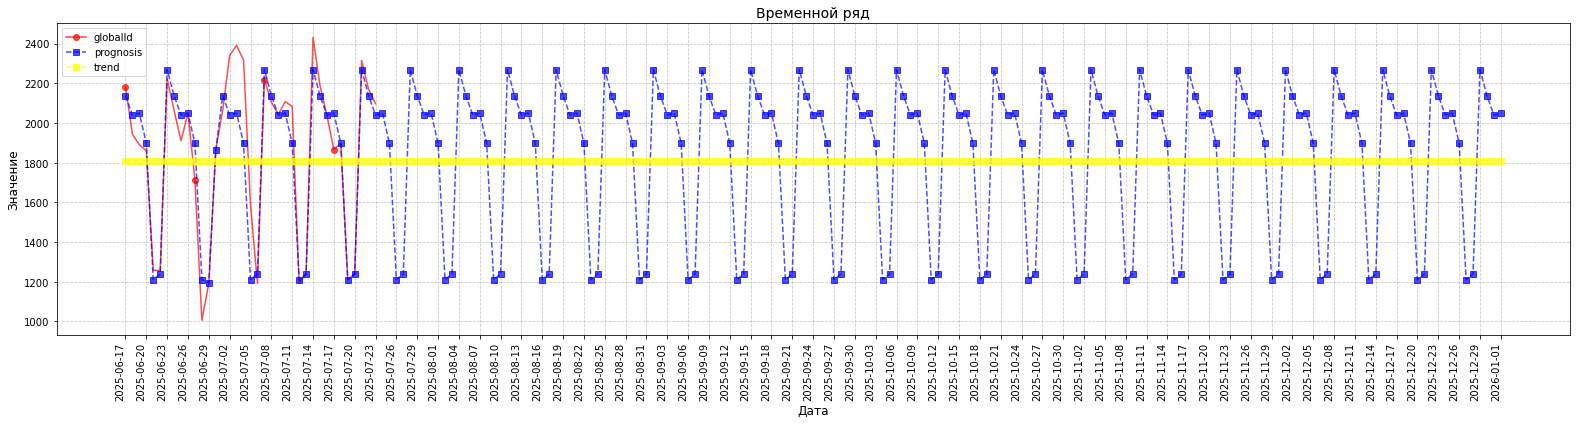

In [7]:
def draw_chart(timeline, historical, prognosis, trend):
    # Создаем график
    plt.figure(figsize=(22, 6))

    # Разделяем построение линий для каждого значения
    # Строим линию для globalId
    plt.plot(timeline, 
             historical, 
             linestyle='-', 
             marker='o',
             markevery=10,
             color='red',  # Цвет для globalId
             alpha=0.7,
             label='globalId')

    # Строим линию для prognosis
    plt.plot(timeline, 
             prognosis, 
             linestyle='--',  # Другой стиль линии
             marker='s', 
             # Другой маркер
             color='blue',    # Цвет для prognosis
             alpha=0.7,
             label='prognosis')
    
        # Строим линию для trend
    plt.plot(timeline, 
             trend, 
             linestyle='--',  # Другой стиль линии
             marker='s', 
             # Другой маркер
             color='yellow',    # Цвет для prognosis
             alpha=0.7,
             label='trend')

    plt.xticks(
        ticks=np.arange(
            timeline.min(), 
            timeline.max() + pd.Timedelta(days=1), 
            pd.Timedelta(days=3)
        ),
        rotation=45,
        ha='right'
    )

    # Настройка осей
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.title('Временной ряд', fontsize=14)

    # Поворот меток по оси X
    plt.xticks(rotation=90, ha='right')

    # Добавляем сетку
    plt.grid(True, linestyle='--', alpha=0.7)

    # Добавляем легенду
    plt.legend(loc='upper left')

    # Отображаем график
    plt.tight_layout()
    plt.show()
    
    display()

draw_chart(prediction_sample_a_final['date'],
           prediction_sample_a_final['globalId'],
           prediction_sample_a_final['prognosis'],
           prediction_sample_a_final['trend'])

***Модуль интервально-дневных коэффициентов***

In [8]:
# В этом блоке собираем данные по нагрузки в разрезе интервалов и перерабатываем выбросы
percentile_h = 0.75
percentile_l = 0.25

class StatisticTables:
    def __init__(self, load_table, team, percentile_h, percentile_l):
        self.load_table = load_table
        self.team = team
        self.percentile_h = percentile_h
        self.percentile_l = percentile_l
        self.load_table = load_table
        
        self.pivot_table_historical = self.create_interval_pivot_table()
        self.pivot_table_processed = self.recalculate_statistics_table()

    # Cобираем сводную таблицу из исторических данных, чтобы сгруппировать нагрузку по датам и дням недели.
    def create_interval_pivot_table(self):
        # Готовим данные
        statistical_table = self.load_table[(self.load_table['team'] == self.team) &
                                  (self.load_table['dateTime_scaled'] >=
                                   (self.load_table['dateTime_scaled'].max() - pd.Timedelta(days=96)))][
            ['dateTime_scaled', 'globalId', 'day', 'hour', 'interval', 'date']]

    # Создаем сводную таблицу с исторической нагрузкой по каждому интервалу
        pivot_table_historical = statistical_table.pivot_table(
            values='globalId',
            index=['hour', 'interval'],
            columns=['day', 'date'],
            aggfunc='median',
            fill_value=0
        )
        pivot_table_historical.to_excel('historical.xlsx', sheet_name='historical')
        return pivot_table_historical

    # Пересчитываем исторические данные, чтобы они были в рамках percentile_h, percentile_l. Если нет - замена на медиану
    def recalculate_statistics_table(self): 
        # Копируем исходную таблицу
        pivot_table_processed = self.pivot_table_historical.copy()

        # Проходим по каждой строке
        for idx, row in pivot_table_processed.iterrows():
            # Проходим по каждому столбцу (день недели)
            for col in pivot_table_processed.columns.levels[0]:
                # Получаем все значения для текущего дня
                values = row[col].values
                # Вычисляем процентили и медиану
                pctl_h = np.percentile(values, self.percentile_h)
                pctl_l = np.percentile(values, self.percentile_l)
                median_val = np.median(values)

            # Заменяем все, что больше указанных выше процентилей путем замены на медиану:
                pivot_table_processed.loc[idx, (col, slice(None))] = np.where(
                    (values > pctl_h) | (values < pctl_l),
                    median_val,
                    values
                )

        pivot_table_processed.to_excel('processed.xlsx', sheet_name='processed')
        return pivot_table_processed

stat_table_a = StatisticTables(prognosis_set_a.load_table,
                               prognosis_set_a.team,
                               percentile_h,
                               percentile_l).pivot_table_processed

In [9]:
# Делаем таблицы со коэффициентами дня 
class CoeffsTableBase:
    def __init__(self, stat_table_a):
        self.stat_table_a = stat_table_a
        self.date_sum = self.find_day_sum()
        self.coeff_interval_table = self.define_coeffs()

    # Найдем суммарную нагрузку для каждой даты, чтобы потом рассчитать % (коэффициент) на каждый интервал
    def find_day_sum(self):
        date_sum = dict()
        day_sum_table = self.stat_table_a.copy()
        for col in day_sum_table.columns:
            date_sum[col] = day_sum_table[col].values.sum()
        return date_sum

    # Рассчитаем коэффициент каждого интервала путем его деления на сумму дня
    def define_coeffs(self):
        coeff_interval_table = self.stat_table_a.copy()
        for col in self.stat_table_a.columns:
            coeff_interval_table[col] = self.stat_table_a[col] / self.date_sum[col]  # Исправлено stat_table_a на self.stat_table_a
        coeff_interval_table.to_excel('coefs.xlsx', sheet_name='coefs')  
        return coeff_interval_table

class CoeffsTable:
    def __init__(self, stat_table_a):
        self.coeff_table = CoeffsTableBase(stat_table_a)
        self.day_coeff_table = self.create_day_coeff_table() 
        self.final_day_coeff_table = self.create_final_day_coeff_table()
        
    # Возьмем медиану диапазона дат, которые относятся ко дню недели, 
    # чтобы рассчитать коэфициенты уже не по дням и датам, а только по дням. 
    def create_day_coeff_table(self):
        coeff_table_buf = self.coeff_table.coeff_interval_table.copy()
        day_coeff_table = pd.DataFrame(np.nan, index=range(96), columns=np.arange(7))
        for col in coeff_table_buf.columns.levels[0]:
            row_number = 0
            for row_idx in coeff_table_buf.index:
                day_coeff_table.loc[row_number, col] = np.median(coeff_table_buf.loc[row_idx, col].values)
                row_number += 1
        return day_coeff_table

    # Рассчитываем итоговую таблицу коэффициентов для всей недели
    def create_final_day_coeff_table(self):
        day_coeff_sum_table = self.day_coeff_table.sum()
        final_day_coeff_table = pd.DataFrame(np.nan, index=range(96), columns=np.arange(7))
        for col in self.day_coeff_table.columns: 
            final_day_coeff_table[col] = self.day_coeff_table[col] / day_coeff_sum_table[col] 
        final_day_coeff_table.to_excel('final_coeffs.xlsx', sheet_name='coeffs')
        return final_day_coeff_table

final_day_coeff_table_a = CoeffsTable(stat_table_a).final_day_coeff_table

**Модуль построения интервального прогноза**

In [14]:
start_date_a, end_date_a = "01.01.2025", "01.01.2026"

class FinalTable:
    def __init__(self, start_date, end_date, final_day_coeff_table, prediction_sample):
        self.start_date = start_date
        self.end_date = end_date
        self.final_day_coeff_table = final_day_coeff_table
        self.prediction_sample = prediction_sample
        self.final_day_dist_table = self.create_final_day_dist_table()
        
    # Рассчитываем количество обращений на каждый интервал по собранным ранее коэффициентам и спрогнозированной нагрузке на день
    def create_final_day_dist_table(self):
        # Готовим пустую таблицу в заданном диапазоне дат
        date_range_final = pd.DataFrame(pd.date_range(start=self.start_date, end=self.end_date), columns=['date'])
        date_range_final['day'] = date_range_final['date'].dt.dayofweek
        final_day_dist_table = date_range_final.transpose()
        final_day_dist_table = final_day_dist_table.reindex(index=np.array(range(96)),
                                                            columns=pd.MultiIndex.from_arrays(date_range_final[['date', 'day']].
                                                                                              values.transpose()))
        # Заполняем Nan на реальные значения 
        for col in final_day_dist_table.columns:
            for row_index in final_day_dist_table[col].index:
                if not self.prediction_sample['prognosis'][self.prediction_sample['date'] == col[0]].empty:
                    final_day_dist_table[col] = (self.prediction_sample['prognosis'][self.prediction_sample['date'] == col[0]].
                                                 values[0])*self.final_day_coeff_table[col[1]]
                    final_day_dist_table = final_day_dist_table.fillna(0)
        return final_day_dist_table

final_day_dist_table = FinalTable(start_date_a,
                                  end_date_a,
                                  final_day_coeff_table_a,
                                  prediction_sample_a_final).final_day_dist_table

# выгружаем финал в Эксель
final_day_dist_table.to_excel('final.xlsx', sheet_name='final')